<a href="https://colab.research.google.com/github/naoya1110/ai_robotics_lab_2026_hands_on/blob/main/Week02_Simple_SGD_Example__with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple SGD Example with PyTorch

This notebook explains how the weights and the biases of neural network models are optimized using the stochastic gradient descent (SGD) method.

In this example, we will implement a simple linear regression model with PyTorch.

First, let's import the PyTorch, NumPy, and Matplotlib packages.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

Here, we create a dataset consisting of $x$ (inputs) and $y$ (outputs) using a simple linear equation below. It's important to note that the output data $y$ contains some random noise.

$y = 5x + 3 + \mathrm{noise}$

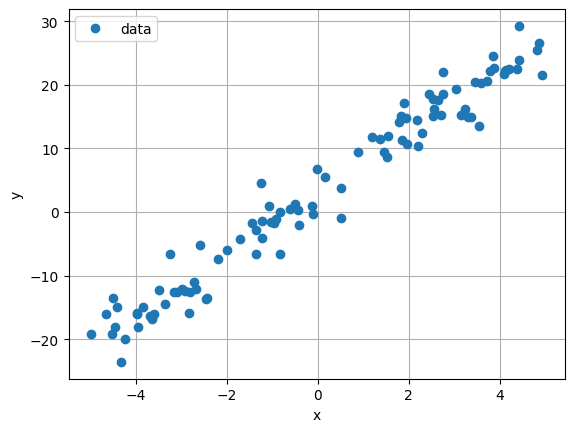

In [2]:
x = 10*np.random.rand(100)-5
noise = 3*np.random.randn(x.shape[0])
y = 5*x + 3 + noise

plt.plot(x, y, marker="o", lw= 0, label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

## Least Squares Polynominal Fit

Our objective is to discover a linear function model (equation) that can effectively capture the relationship between the $x$ and $y$ dataset.

In fact, instead of employing PyTorch, we can use `np.polyfit()` to fit the dataset. This allows us to acquire the fitting parameters $w$ and $b$ for the linear function of $y = wx + b$, where $w$ and $b$ are referred to as the weight and bias, respectively."

In [3]:
w, b = np.polyfit(x, y, 1)
print(f"w={w:.3f}, b={b:.3f}")

w=4.820, b=3.016


Due to the presence of noise in the $x-y$ dataset, the obtained values of $w$ and $b$ may not match the exact values used to create the dataset. Nevertheless, they are typically close enough to allow us to create a fitting line using these parameters.

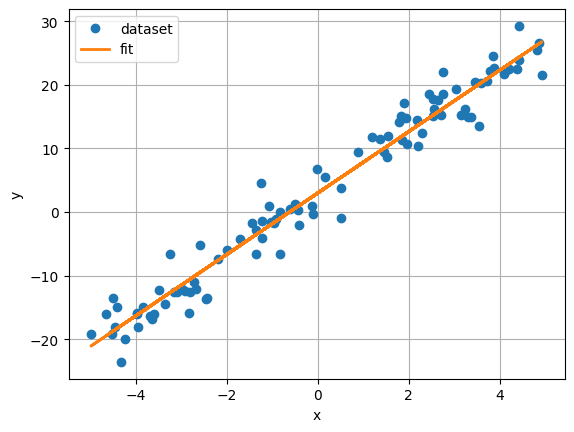

In [4]:
y_fit = w*x + b

plt.plot(x, y, marker="o", lw=0, label="dataset")
plt.plot(x, y_fit, lw=2, label="fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

## Stocastic Gradient Descent

While `np.polyfit()` works effectively, in this example, we will achieve the same outcome using PyTorch.

Let's start by converting the $x$ and $y$ dataset into `torch.tensor` objects.

In [5]:
x = torch.tensor(x)
y = torch.tensor(y)

print(type(x))
print(type(y))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


Next, we define a function named `model()` that outputs the predicted value `p` from an input value `x` using the parameters `w` and `b`.

In [6]:
def model(x):
    p = w*x + b
    return p

We also define a function named `loss_func()` to calculate the mean squared error between `p` and `y`. This type of function is referred to as a loss function, which helps measure the degree of error in the model's predictions.

$\displaystyle \mathrm{loss} = \mathrm{mse}(p, y) = \frac{1}{N}\sum_{i=0}^{N-1}(p_i-y_i)^2$

In [7]:
def loss_func(p, y):
    loss = ((p-y)**2).mean()
    return loss

At this stage, we haven't determined the values of `w` and `b` yet. Therefore, we initialize these values with arbitrary numbers.

In [8]:
w = torch.tensor(1.0, requires_grad=True)   # you can set any number here
b = torch.tensor(-5.0, requires_grad=True)  # you can set any number here

Now, we can make a prediction using `model()`

In [9]:
p = model(x)
print(p)

tensor([-5.6126, -2.4538, -5.1325, -2.2380, -9.6644, -3.4807, -8.4964, -1.2076,
        -3.6320, -9.5363, -0.9032, -5.9603, -6.2434, -3.1607, -9.3374, -3.8082,
        -1.7654, -1.4165, -5.4114, -9.9920, -3.1264, -9.4719, -3.2149, -0.5767,
        -5.8350, -1.1388, -6.4409, -7.7363, -5.9121, -5.5114, -9.4181, -8.1064,
        -2.4644, -5.0118, -3.0354, -4.4934, -8.6904, -3.5532, -1.2882, -0.7955,
        -6.0314, -7.5912, -1.8446, -0.1746, -0.6288, -6.3625, -1.5338, -5.8374,
        -9.5194, -6.0871, -2.8130, -2.2845, -0.5649, -2.4561, -6.9992, -0.8893,
        -3.1147, -1.4557, -1.9568, -7.6898, -8.6054, -4.8446, -7.9813, -1.6881,
        -3.1599, -2.3577, -5.4399, -7.8117, -0.0684, -7.9161, -4.1098, -2.5603,
        -3.0606, -8.6547, -0.8634, -0.1340, -4.4908, -9.2430, -7.4501, -7.4621,
        -1.6242, -8.9722, -6.2251, -6.7189, -2.8079, -8.3757, -6.2402, -8.8514,
        -5.1099, -8.1765, -3.4483, -1.1196, -6.3617, -2.2431, -7.2016, -8.9505,
        -2.7103, -7.8292, -8.9906, -8.25

Let's visualize the current prediction. Since we've initialized `w` and `b` with arbitrary numbers, it's expected that the model's prediction won't fit the data well.

Text(0, 0.5, 'y')

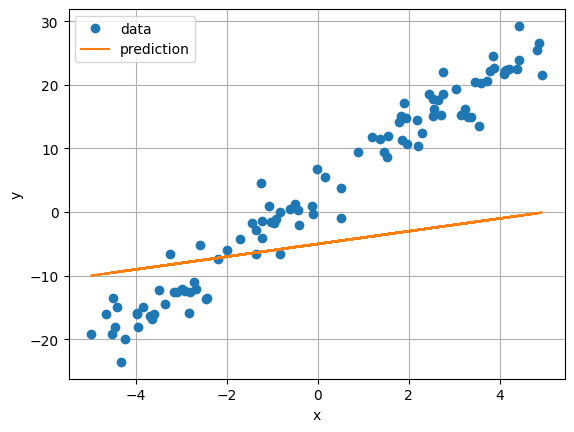

In [10]:
plt.plot(x, y, marker="o", lw=0, label="data")
plt.plot(x, p.detach().numpy(), label="prediction")
plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

Next, we calculate the loss value (mean squared error) using `loss_func()`. It's important to note that the loss value will be very large because `w` and `b` are arbitrary values and have not been optimized yet.

In [11]:
loss = loss_func(p, y)
print(loss)

tensor(205.0971, dtype=torch.float64, grad_fn=<MeanBackward0>)


To optimize `w` and `b`, we must determine the gradients of the loss with respect to the current values of `w` and `b`. This can be achieved using `loss.backward()`. The gradients, denoted as $\displaystyle \frac{\partial \mathrm{loss}}{\partial w}$ and $\displaystyle \frac{\partial \mathrm{loss}}{\partial b}$, can be accessed by `w.grad` and `b.grad`, respectively.

In [12]:
loss.backward()
print(w.grad)
print(b.grad)

tensor(-67.9568)
tensor(-16.8553)


We can update `w` and `b` using the following equations, where $\eta$ represents the learning rate. This method is known as stochastic gradient descent (SGD):

$\displaystyle w := w - \eta\frac{\partial\mathrm{loss}}{\partial w}$

$\displaystyle b := b - \eta\frac{\partial\mathrm{loss}}{\partial b}$

When updating these values, we don't want to compute gradients. To achieve this, we use with `torch.no_grad()` at the beginning.

In [13]:
lr = 0.01    # define learning rate

with torch.no_grad():    # disable gradients calculations
    w -= w.grad*lr       # update w
    b -= b.grad*lr       # update b

At this stage, you'll notice that the values of `w` and `b` are closer to their true values ($w$=5.0, $b$=3.0) compared to the initial values.

In [14]:
print(w)
print(b)

tensor(1.6796, requires_grad=True)
tensor(-4.8314, requires_grad=True)


To further optimize `w` and `b`, we repeat the above process multiple times.

In [15]:
w = torch.tensor(1.0, requires_grad=True)   # you can set any number here
b = torch.tensor(-5.0, requires_grad=True)  # you can set any number here

lr = 0.01    # learning rate
epochs = 300  # how many times we repeat training

w = torch.tensor(3.0, requires_grad=True)    # initialize w
b = torch.tensor(-1.0, requires_grad=True)   # initialize b

# empty lists for saving loss, w, b
loss_list = []
w_list = []
b_list = []

for epoch in range(epochs):

    p = model(x)              # prediction
    loss = loss_func(p, y)    # measure loss
    loss.backward()           # determine gradients

    with torch.no_grad():     # disable autograd
        w -= w.grad*lr        # update w
        b -= b.grad*lr        # update b

        w.grad.zero_() # reset gradient
        b.grad.zero_() # reset gradient

    # save loss, w, b
    loss_list.append(loss.item())
    w_list.append(w.item())
    b_list.append(b.item())

    print(f"Epoch {epoch+1}, loss={loss.item():.3f}, w={w.item():.3f}, b={b.item():.3f}")

Epoch 1, loss=54.166, w=3.324, b=-0.916
Epoch 2, loss=43.873, w=3.592, b=-0.834
Epoch 3, loss=36.666, w=3.813, b=-0.754
Epoch 4, loss=31.575, w=3.996, b=-0.677
Epoch 5, loss=27.935, w=4.147, b=-0.601
Epoch 6, loss=25.294, w=4.271, b=-0.527
Epoch 7, loss=23.342, w=4.374, b=-0.455
Epoch 8, loss=21.865, w=4.459, b=-0.385
Epoch 9, loss=20.720, w=4.528, b=-0.316
Epoch 10, loss=19.806, w=4.586, b=-0.249
Epoch 11, loss=19.055, w=4.634, b=-0.183
Epoch 12, loss=18.421, w=4.673, b=-0.119
Epoch 13, loss=17.872, w=4.705, b=-0.056
Epoch 14, loss=17.384, w=4.731, b=0.006
Epoch 15, loss=16.944, w=4.753, b=0.066
Epoch 16, loss=16.540, w=4.771, b=0.126
Epoch 17, loss=16.165, w=4.786, b=0.183
Epoch 18, loss=15.814, w=4.798, b=0.240
Epoch 19, loss=15.482, w=4.807, b=0.296
Epoch 20, loss=15.168, w=4.815, b=0.350
Epoch 21, loss=14.869, w=4.822, b=0.404
Epoch 22, loss=14.584, w=4.827, b=0.456
Epoch 23, loss=14.311, w=4.831, b=0.507
Epoch 24, loss=14.050, w=4.835, b=0.557
Epoch 25, loss=13.800, w=4.837, b=0.

As you can see now, `w` is now close to 5.0, and `b` is close to 3.0.

Let's visualize how the loss value has decreased.

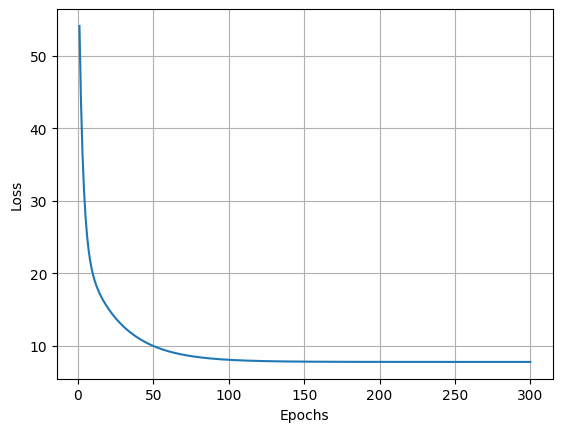

In [16]:
plt.plot(np.arange(epochs)+1, loss_list)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()

Let's visualize how the `w` value has changed.

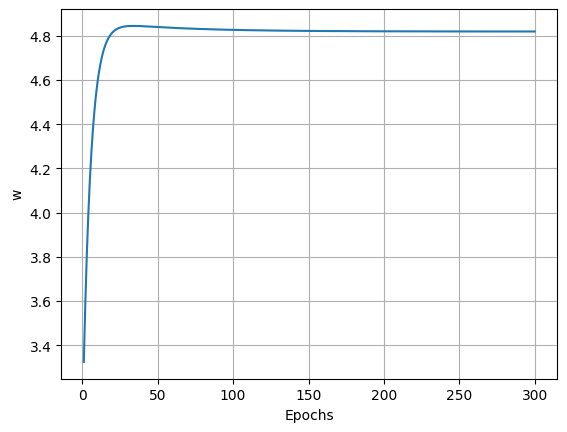

In [17]:
plt.plot(np.arange(epochs)+1, w_list)
plt.xlabel("Epochs")
plt.ylabel("w")
plt.grid()

Let's visualize how the `b` value has changed.

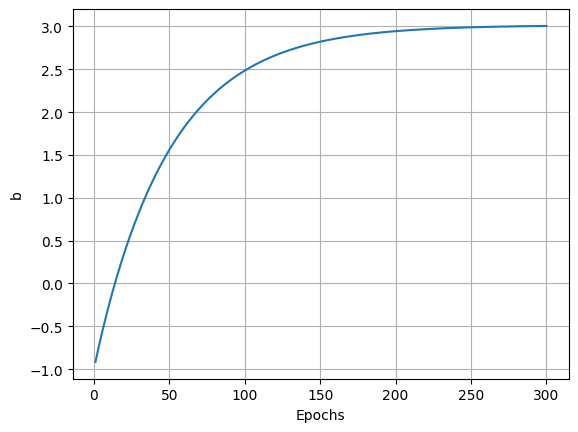

In [18]:
plt.plot(np.arange(epochs)+1, b_list)
plt.xlabel("Epochs")
plt.ylabel("b")
plt.grid()

With the optimized values of `w` and `b`, the model fits the dataset very well.

Text(0, 0.5, 'y')

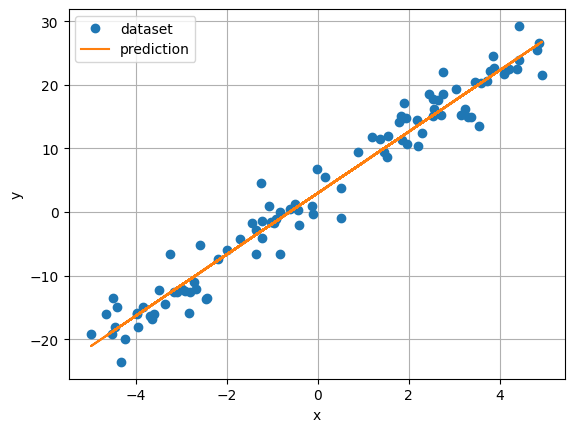

In [19]:
plt.plot(x, y, marker="o", lw=0, label="dataset")
plt.plot(x, p.detach().numpy(), label="prediction")
plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

Now you can try to change initial values of `epochs`, `lr`, `w`, `b` etc., and let's observe the results.